In [2]:
import pandas as pd

In [3]:
#df = pd.read_csv("D:\\dattu\\Data Science\\05_MachineLearning\\ML_Projects\\02_Fake_Review_Detector\\Data\\fake reviews dataset.csv")


In [4]:
# df.head()

In [5]:
# df.columns

In [6]:
# df["label"].value_counts()

In [7]:
df = pd.read_csv("D:\\dattu\\Data Science\\05_MachineLearning\\ML_Projects\\02_Fake_Review_Detector\\Data\\deceptive-opinion.csv")

In [8]:
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


In [9]:
df.shape

(1600, 5)

In [10]:
df.columns.tolist()

['deceptive', 'hotel', 'polarity', 'source', 'text']

In [11]:
df["deceptive"].value_counts()

deceptive
truthful     800
deceptive    800
Name: count, dtype: int64

## Initial Dataset Observations

The dataset contains **1,600 hotel reviews** and **5 columns**:

- **`deceptive`** – Indicates whether the review is **truthful or deceptive**. This is our **target variable (`y`)**.
- **`hotel`** – The name of the hotel being reviewed.
- **`polarity`** – Indicates whether the review is positive or negative.
- **`source`** – Indicates the source/type of the review.
- **`text`** – The actual written review. This will be our main **input feature (`X`)**.

### Target Distribution

The dataset is perfectly balanced:

- **Truthful reviews:** 800
- **Deceptive reviews:** 800

Therefore, the dataset has an equal number of reviews from both classes, which is beneficial for training and evaluating a binary classification model.

### Initial Approach

For the first version of the model, we will focus mainly on:

- **`text` → Input feature (`X`)**
- **`deceptive` → Target variable (`y`)**

The other columns will not be used initially because our goal is to build a model that learns to classify a review as **truthful or deceptive based primarily on the review text**.

In [12]:
df.info

<bound method DataFrame.info of       deceptive             hotel  polarity       source  \
0      truthful            conrad  positive  TripAdvisor   
1      truthful             hyatt  positive  TripAdvisor   
2      truthful             hyatt  positive  TripAdvisor   
3      truthful              omni  positive  TripAdvisor   
4      truthful             hyatt  positive  TripAdvisor   
...         ...               ...       ...          ...   
1595  deceptive  intercontinental  negative        MTurk   
1596  deceptive            amalfi  negative        MTurk   
1597  deceptive  intercontinental  negative        MTurk   
1598  deceptive            palmer  negative        MTurk   
1599  deceptive            amalfi  negative        MTurk   

                                                   text  
0     We stayed for a one night getaway with family ...  
1     Triple A rate with upgrade to view room was le...  
2     This comes a little late as I'm finally catchi...  
3     The Omni 

In [13]:
df.isnull().sum()

deceptive    0
hotel        0
polarity     0
source       0
text         0
dtype: int64

In [14]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1595    False
1596    False
1597    False
1598    False
1599    False
Length: 1600, dtype: bool>

In [15]:
df["text"].duplicated().sum()

np.int64(4)

In [16]:
df["text"].nunique()

1596

In [17]:
duplicates =df[df["text"].duplicated(keep=False)]

In [18]:
duplicates[["deceptive", "text"]].sort_values("text")

,deceptive,text
995,truthful,"I'd been searching for a cool, non-chain hotel..."
1014,truthful,"I'd been searching for a cool, non-chain hotel..."
803,truthful,My daughter and I woke in the morning wanting ...
853,truthful,My daughter and I woke in the morning wanting ...
847,truthful,The Omni was chosen for it's location whichwor...
862,truthful,The Omni was chosen for it's location whichwor...
1085,truthful,Very disappointed in our stay in Chicago Monoc...
1109,truthful,Very disappointed in our stay in Chicago Monoc...


In [19]:
df = df.drop_duplicates(subset=["text"])

In [20]:
df.shape

(1596, 5)

In [21]:
df["text"].duplicated().sum()

np.int64(0)

In [22]:
df["text"].str.len().describe()

count    1596.000000
mean      806.052632
std       467.288066
min       151.000000
25%       487.000000
50%       699.500000
75%       987.500000
max      4159.000000
Name: text, dtype: float64

In [23]:
df.groupby("deceptive")["text"].apply(lambda x: x.str.len().describe())

deceptive       
deceptive  count     800.000000
           mean      791.767500
           std       449.016264
           min       151.000000
           25%       483.750000
           50%       680.500000
           75%       985.000000
           max      4075.000000
truthful   count     796.000000
           mean      820.409548
           std       484.817329
           min       168.000000
           25%       491.000000
           50%       710.500000
           75%       993.250000
           max      4159.000000
Name: text, dtype: float64

## Review Length Analysis

The dataset contains reviews with an average length of approximately **806 characters**.

- **Shortest review:** 151 characters
- **Longest review:** 4,159 characters
- **Average review length:** approximately 806 characters
- **Median review length:** approximately 700 characters

### Comparison Between Classes

After comparing review lengths:

- **Deceptive reviews:** Average length of approximately 792 characters
- **Truthful reviews:** Average length of approximately 820 characters

Truthful reviews are slightly longer on average than deceptive reviews. However, the difference is relatively small compared to the variation in review lengths.

Therefore, **review length alone is unlikely to be sufficient for classifying a review as truthful or deceptive**. The model will need to learn patterns from the actual words and language used in the reviews.

In [24]:
df.groupby("deceptive")["text"].apply(lambda x: x.iloc[0])

deceptive
deceptive    My husband and I visited the Fairmont Chicago ...
truthful     We stayed for a one night getaway with family ...
Name: text, dtype: str

In [25]:
print("DECEPTIVE REVIEW:\n")
print(df[df["deceptive"] == "deceptive"]["text"].iloc[0])

print("\n" + "="*80 + "\n")

print("TRUTHFUL REVIEW:\n")
print(df[df["deceptive"] == "truthful"]["text"].iloc[0])

DECEPTIVE REVIEW:

My husband and I visited the Fairmont Chicago Millennium Park for our honeymoon. The customer service was amazing. From the time we booked our packege to the time we checked in everything was absolutely amazing. These people were proficient, respectful and very thoughtful. The Fairmont had a lounge, a wine room, a bar and a restaurant. I couldn't decide where I wanted to go first! After we put our bags up we headed down to the wine room... It was totally delicious. We also got free wine just because it was our honeymoon! Then after a few glasses of wine we hit the spa, once again excellent!! Everything smells like honeysuckle and everyone smiles all the time. We stayed in the gold room. Although it was a little bit smaller than I thought it would be I was definitely satisfied with the huge king bed with even bigger pillows. My husband and I relaxed in fluffy white bath robes while we sipped champagne while we watched the sparkling lights of the city. It was a wonderf

In [26]:
X = df["text"]
y = df["deceptive"]

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train: (1276,)
X_test: (320,)

Training target distribution:
deceptive
deceptive    640
truthful     636
Name: count, dtype: int64

Testing target distribution:
deceptive
truthful     160
deceptive    160
Name: count, dtype: int64


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [31]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [32]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1276, 8651)
Testing TF-IDF shape: (320, 8651)


In [33]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['00' '000' '00am' '00pm' '03' '06' '07' '08' '09' '10' '100' '105' '107'
 '10am' '10pm' '10th' '10x' '11' '110' '11am' '11th' '12' '120' '122'
 '125' '127' '129' '12am' '12th' '13']


In [34]:
print("Original Review:\n")
print(X_train.iloc[0])

Original Review:

I accompanied my husband on a business trip to Chicago back in September and we stayed at the Millennium Knickerbocker Hotel. The place was absolutely oozing with old-fashioned charm! Also, there were plenty of shopping opportunities within walking distance, so I shopped while my husband worked. It just doesn't get any better than that! I loved the service we received and the ambiance of that grand old hotel, and I'd definitely stay there again!



In [35]:
print("\nTF-IDF Representation:\n")
print(X_train_tfidf[0])


TF-IDF Representation:

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 57 stored elements and shape (1, 8651)>
  Coords	Values
  (0, 295)	0.2266065000415433
  (0, 5028)	0.09923717701086539
  (0, 3880)	0.2195118267144114
  (0, 5278)	0.053675000097055246
  (0, 1262)	0.09783570694189847
  (0, 7954)	0.10477620510399246
  (0, 7805)	0.03630864916034736
  (0, 1504)	0.05039151676074505
  (0, 829)	0.0874479759762534
  (0, 3961)	0.0382162909927978
  (0, 6725)	0.18233815923814947
  (0, 534)	0.1022222899235514
  (0, 8418)	0.11252817234110003
  (0, 7278)	0.06842501410459356
  (0, 733)	0.044583351946532616
  (0, 7688)	0.13481019383367662
  (0, 4869)	0.14070103333971112
  (0, 4301)	0.14480723904994539
  (0, 3832)	0.07789810937712909
  (0, 5640)	0.08784433647529069
  (0, 8384)	0.03855015219329993
  (0, 263)	0.13647119488932022
  (0, 5289)	0.249821434818264
  (0, 8532)	0.05065317489846364
  (0, 5266)	0.2454052807273401
  :	:
  (0, 6828)	0.11325626011259954
  (0, 5302)	0.2266065000415433

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [38]:
y_pred = model.predict(X_test_tfidf)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.875


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   deceptive       0.88      0.86      0.87       160
    truthful       0.87      0.89      0.88       160

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.87       320
weighted avg       0.88      0.88      0.87       320



In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[138  22]
 [ 18 142]]


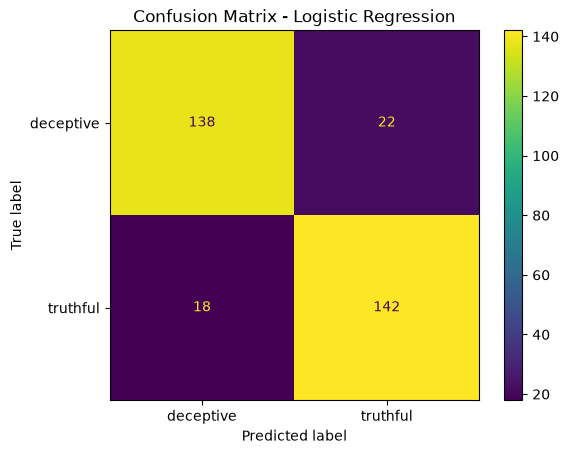

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
plt.savefig("D:\\dattu\\Data Science\\05_MachineLearning\\ML_Projects\\02_Fake_Review_Detector\\Outputs\\confusion_matrix.png", dpi=300, bbox_inches='tight')

Naive Bayes Accuracy: 0.871875

Classification Report:

              precision    recall  f1-score   support

   deceptive       0.82      0.95      0.88       160
    truthful       0.94      0.79      0.86       160

    accuracy                           0.87       320
   macro avg       0.88      0.87      0.87       320
weighted avg       0.88      0.87      0.87       320



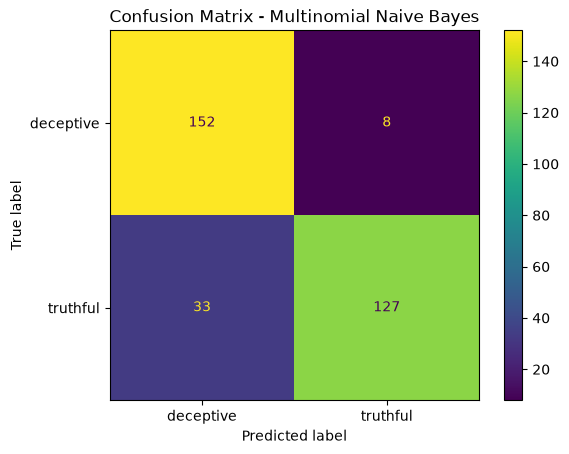

<Figure size 640x480 with 0 Axes>

In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Make predictions
nb_y_pred = nb_model.predict(X_test_tfidf)

# Accuracy
nb_accuracy = accuracy_score(y_test, nb_y_pred)
print("Naive Bayes Accuracy:", nb_accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, nb_y_pred))

# Confusion Matrix
nb_cm = confusion_matrix(y_test, nb_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=nb_model.classes_
)

disp.plot()
plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.show()
plt.savefig("D:\\dattu\\Data Science\\05_MachineLearning\\ML_Projects\\02_Fake_Review_Detector\\Outputs\\confusion_matrix_nb.png", dpi=300, bbox_inches='tight')

## Model Comparison

Two models were trained and evaluated using TF-IDF features:

| Model | Accuracy | Observation |
|---|---:|---|
| Logistic Regression | 87.5% | More balanced performance across both classes |
| Multinomial Naive Bayes | ~87% | Higher recall for deceptive reviews but lower recall for truthful reviews |

Logistic Regression was selected as the final model because it achieved slightly higher accuracy and showed more balanced performance between deceptive and truthful reviews.

In [44]:
custom_reviews = [
    "The hotel was fantastic. The room was clean, the staff were helpful, and the location was perfect.",
    
    "Absolutely the most incredible hotel in the entire world! Everything was perfect beyond imagination. I will never stay anywhere else!",
    
    "The room was small and check-in took a long time, but the location was convenient and the staff were polite.",
    
    "Amazing amazing amazing! Best experience ever! Everyone must stay here!"
]
custom_tfidf = tfidf.transform(custom_reviews)

In [45]:
custom_predictions = model.predict(custom_tfidf)

In [46]:
for review, prediction in zip(custom_reviews, custom_predictions):
    print("Review:", review)
    print("Prediction:", prediction)
    print("-" * 100)

Review: The hotel was fantastic. The room was clean, the staff were helpful, and the location was perfect.
Prediction: truthful
----------------------------------------------------------------------------------------------------
Review: Absolutely the most incredible hotel in the entire world! Everything was perfect beyond imagination. I will never stay anywhere else!
Prediction: truthful
----------------------------------------------------------------------------------------------------
Review: The room was small and check-in took a long time, but the location was convenient and the staff were polite.
Prediction: truthful
----------------------------------------------------------------------------------------------------
Review: Amazing amazing amazing! Best experience ever! Everyone must stay here!
Prediction: deceptive
----------------------------------------------------------------------------------------------------


In [47]:
custom_probabilities = model.predict_proba(custom_tfidf)

for review, prediction, probability in zip(
    custom_reviews,
    custom_predictions,
    custom_probabilities
):
    print("Review:", review)
    print("Prediction:", prediction)
    print(
        "Confidence:",
        round(max(probability) * 100, 2),
        "%"
    )
    print("-" * 100)

Review: The hotel was fantastic. The room was clean, the staff were helpful, and the location was perfect.
Prediction: truthful
Confidence: 61.76 %
----------------------------------------------------------------------------------------------------
Review: Absolutely the most incredible hotel in the entire world! Everything was perfect beyond imagination. I will never stay anywhere else!
Prediction: truthful
Confidence: 51.49 %
----------------------------------------------------------------------------------------------------
Review: The room was small and check-in took a long time, but the location was convenient and the staff were polite.
Prediction: truthful
Confidence: 71.63 %
----------------------------------------------------------------------------------------------------
Review: Amazing amazing amazing! Best experience ever! Everyone must stay here!
Prediction: deceptive
Confidence: 68.01 %
--------------------------------------------------------------------------------------

In [49]:
import joblib

joblib.dump(model, "D:\\dattu\\Data Science\\05_MachineLearning\\ML_Projects\\02_Fake_Review_Detector\\Models\\fake_review_model.pkl")
joblib.dump(tfidf, "D:\\dattu\\Data Science\\05_MachineLearning\\ML_Projects\\02_Fake_Review_Detector\\Models\\tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!
